# NowcastNet Demo
本 Notebook 将完成从数据准备、两阶段训练到最终评估的整个 NowcastNet 工作流。我们将主要使用命令行来执行各个步骤。

在开始之前，请确保已经完成了以下准备工作：
1.  **克隆或下载项目代码**：确保所有脚本 (`nowcastnet_train.py`, `evaluate.py` 等) 和配置文件都在当前工作目录中。
2.  **安装依赖**：已按照 `README.md` 的说明安装了 `paddlepaddle-gpu`, `ppsci`, `hydra-core` 等所有必要的库。
3.  **准备数据集**：已将 `.png` 格式的雷达数据文件放置在 `datasets/mrms` 目录中。
4.  **检查配置文件**：已确认 `conf/train.yaml` 和 `conf/nowcastnet.yaml` 中的 `TRAIN_DATA_PATH` 等路径设置正确。

导入以下核心函数

In [1]:
import os
import paddle
from omegaconf import OmegaConf, DictConfig
import hydra
from hydra import initialize, compose
import hydra

from nowcastnet_train import train_evolution, train_generation
from evaluate import evaluate           
from nowcastnet import evaluate as visualize_func # nowcastnet.py中的evaluate函数用于可视化

print(f"PaddlePaddle Version: {paddle.__version__}")
print("Environment setup complete.")

Pysteps configuration file found at: /mtc/longlingkun/miniconda3/envs/torch251/lib/python3.11/site-packages/pysteps/pystepsrc

PaddlePaddle Version: 3.0.0
Environment setup complete.


## 1. 加载和修改配置
我们将使用 Hydra 的 compose API 在代码中加载和修改配置，这比直接编辑 YAML 文件更灵活。

In [11]:
# 初始化 Hydra 配置环境
# config_path 指向存放 .yaml 文件的目录
initialize(config_path="./conf", version_base=None)

# --- 加载训练配置 ---
# compose API 用于加载指定的配置文件
cfg_train = compose(config_name="train.yaml")
print("--- Initial Training Config ---")
print(OmegaConf.to_yaml(cfg_train))

# --- 加载评估配置 ---
cfg_eval = compose(config_name="nowcastnet.yaml")
print("\n--- Initial Evaluation Config ---")
print(OmegaConf.to_yaml(cfg_eval))

--- Initial Training Config ---
mode: train
output_dir: ./outputs_notebook
log_freq: 20
seed: 42
use_vdl: false
use_tbd: false
wandb_config: {}
use_wandb: false
device: null
use_amp: false
amp_level: O1
to_static: false
prim: false
log_level: info
TRAIN:
  epochs: 1
  iters_per_epoch: 20
  update_freq: 1
  save_freq: 10
  eval_during_train: true
  start_eval_epoch: 1
  eval_freq: 5
  checkpoint_path: null
  pretrained_model_path: null
  ema:
    use_ema: false
    decay: 0.9
    avg_freq: 1
  swa:
    use_swa: false
    avg_freq: 1
    avg_range: null
  module_name: generation
  epochs_evo: 50
  epochs_evo_full: 15
  epochs_gan: 30
  epochs_gan_full: 10
  TRAIN_DATA_PATH: datasets/mrms/figure
  VALID_DATA_PATH: datasets/mrms/figure
  FULL_TRAIN_PATH: /mtc/longlingkun/workspace/datasets_mind/download-mindspore.osinfra.cn/mindscience/mindearth/dataset/nowcastnet/tiny_datasets/train
  FULL_VALID_PATH: /mtc/longlingkun/workspace/datasets_mind/download-mindspore.osinfra.cn/mindscience/minde

## 2. 阶段一：训练演化网络 (Evolution Network)
现在，我们调用 train_evolution 函数来开始第一阶段的训练。
由于本notebook仅作演示功能，故这里只训50个epochs，且数据集为10个样本的小样本。

In [4]:
print("Starting Stage 1: Evolution Network Training...")

# 直接调用函数并传入配置对象
train_evolution(cfg_train)

print("\nStage 1 training complete.")
print("Checkpoints are saved in:", os.path.join(cfg_train.output_dir, "checkpoints_evo"))

# 记下最后一次训练的模型路径，用于下一阶段
evo_best_model_path = os.path.join(cfg_train.output_dir, "checkpoints_evo/epoch_50/model.pdparams")
print(f"Best evolution model path (example): {evo_best_model_path}")

Starting Stage 1: Evolution Network Training...
[2025/06/14 22:10:12] ppsci WARNING: Logger has already been automatically initialized as `log_file` is set to None by default, information will only be printed to terminal without writing to any file.
[2025/06/14 22:10:12] ppsci INFO: Starting Evolution Network Training Phase...


W0614 22:10:12.916568 286959 gpu_resources.cc:114] Please NOTE: device: 0, GPU Compute Capability: 9.0, Driver API Version: 12.8, Runtime API Version: 12.8


[2025/06/14 22:10:13] ppsci INFO: Evolution model, optimizer, and loss function created.
[2025/06/14 22:10:13] ppsci INFO: No Evolution checkpoint found, starting from scratch.
num_batches = 1
[2025/06/14 22:10:18] ppsci INFO: Evo-Train | Epoch 1/50, Batch 1/1, Loss: 687.3862, LR: 1.00e-03
[2025/06/14 22:10:18] ppsci INFO: Evo-Train | Epoch 1/50 Finished | Average Loss: 687.3862, Current LR: 1.00e-03
[2025/06/14 22:10:21] ppsci INFO: Evo-Train | Epoch 2/50, Batch 1/1, Loss: 557.4152, LR: 1.00e-03
[2025/06/14 22:10:21] ppsci INFO: Evo-Train | Epoch 2/50 Finished | Average Loss: 557.4152, Current LR: 1.00e-03
[2025/06/14 22:10:24] ppsci INFO: Evo-Train | Epoch 3/50, Batch 1/1, Loss: 520.4656, LR: 1.00e-03
[2025/06/14 22:10:24] ppsci INFO: Evo-Train | Epoch 3/50 Finished | Average Loss: 520.4656, Current LR: 1.00e-03
[2025/06/14 22:10:27] ppsci INFO: Evo-Train | Epoch 4/50, Batch 1/1, Loss: 499.6403, LR: 1.00e-03
[2025/06/14 22:10:27] ppsci INFO: Evo-Train | Epoch 4/50 Finished | Average 

## 3. 阶段二：训练生成网络 (Generative Network)
开始第二阶段之前，我们需要动态地更新训练配置，将第一阶段产出的最佳模型路径设置好。

In [5]:
# --- 更新训练配置 ---
# 使用 OmegaConf 的点操作符来修改配置
print(f"Setting evolution_checkpoint_path to: {evo_best_model_path}")
cfg_train.TRAIN.evolution_checkpoint_path = evo_best_model_path

# 验证配置是否更新成功
print("\n--- Updated Training Config for Stage 2 ---")
print(OmegaConf.to_yaml(cfg_train))

# --- 开始第二阶段训练 ---
print("\nStarting Stage 2: Generative Network Training...")
train_generation(cfg_train)

print("\nStage 2 training complete.")
print("Checkpoints are saved in:", os.path.join(cfg_train.output_dir, "checkpoints_gan"))

# 记下GAN阶段的最佳模型路径
gan_best_model_path = os.path.join(cfg_train.output_dir, "checkpoints_gan/epoch_30/model_gen.pdparams")
print(f"Best generative model path (example): {gan_best_model_path}")

Setting evolution_checkpoint_path to: ./outputs_notebook/checkpoints_evo/epoch_50/model.pdparams

--- Updated Training Config for Stage 2 ---
mode: train
output_dir: ./outputs_notebook
log_freq: 20
seed: 42
use_vdl: false
use_tbd: false
wandb_config: {}
use_wandb: false
device: null
use_amp: false
amp_level: O1
to_static: false
prim: false
log_level: info
TRAIN:
  epochs: 1
  iters_per_epoch: 20
  update_freq: 1
  save_freq: 10
  eval_during_train: true
  start_eval_epoch: 1
  eval_freq: 5
  checkpoint_path: null
  pretrained_model_path: null
  ema:
    use_ema: false
    decay: 0.9
    avg_freq: 1
  swa:
    use_swa: false
    avg_freq: 1
    avg_range: null
  module_name: generation
  epochs_evo: 50
  epochs_evo_full: 15
  epochs_gan: 30
  epochs_gan_full: 10
  TRAIN_DATA_PATH: datasets/mrms/figure
  VALID_DATA_PATH: datasets/mrms/figure
  FULL_TRAIN_PATH: /mtc/longlingkun/workspace/datasets_mind/download-mindspore.osinfra.cn/mindscience/mindearth/dataset/nowcastnet/tiny_datasets/tra

## 4. 阶段三：合并权重
调用封装好的 merge_weights_func 函数来创建最终用于评估的模型。

In [6]:
from merge_weights import merge_weights_func
final_model_path = merge_weights_func(
    evo_best_model_path,
    gan_best_model_path,
    "final_model_for_eval" # 指定保存目录
)

print(f"\nWeights successfully merged. Final model saved at: {final_model_path}")

Loading weights from both stages...
Merging weights...
  - Taking 'evo_net.gamma' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.0.weight' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.0.bias' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.0._mean' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.0._variance' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.2.bias' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.2.weight_orig' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.2.weight_u' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.2.weight_v' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.3.weight' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.3.bias' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.3._mean' from evolution stage weights.
  - Taking 'evo_net.inc.double_conv.3._variance'

## 5. 阶段四：模型评估
最后，我们使用合并后的最终模型进行定性和定量评估。

In [7]:
# 如果使用上述训练好的模型的话：动态更新评估配置，指向最终模型
print(f"Updating evaluation model path to: {final_model_path}")
cfg_eval.EVAL.pretrained_model_path = final_model_path

print("\n--- Updated Evaluation Config ---")
print(OmegaConf.to_yaml(cfg_eval))

Updating evaluation model path to: None

--- Updated Evaluation Config ---
mode: train
output_dir: ${hydra:run.dir}
log_freq: 5
seed: 42
use_vdl: false
use_tbd: false
wandb_config: {}
use_wandb: false
device: null
use_amp: false
amp_level: O1
to_static: false
prim: false
log_level: info
TRAIN:
  epochs: 1000
  iters_per_epoch: -1
  update_freq: 1
  save_freq: 5
  eval_during_train: true
  start_eval_epoch: 1
  eval_freq: 5
  checkpoint_path: null
  pretrained_model_path: null
  ema:
    use_ema: false
    decay: 0.9
    avg_freq: 1
  swa:
    use_swa: false
    avg_freq: 1
    avg_range: null
  batch_size: 2
  num_workers: 4
  learning_rate_evo: 0.001
  learning_rate_gen: 3.0e-05
  learning_rate_disc: 3.0e-05
  lambda_motion: 0.01
  beta_adv: 6.0
  gamma_pool: 20.0
  ensemble_k: 4
  pool_size: 2
  TRAIN_DATA_PATH: datasets/mrms/figure
  VALID_DATA_PATH: datasets/mrms/figure
  log_freq: 20
EVAL:
  pretrained_model_path: /mtc/longlingkun/workspace/PaddleScience/examples/nowcastnet/final_

由于demo中的模型训练时间与样本太少，这里切换为完整训练后的的模型。您可以自行下载预训练好的模型进行测试。
1. 运行定性可视化评估

In [12]:
print("\nRunning qualitative visualization (from nowcastnet.py)...")

# 调用 nowcastnet.py 中的评估函数 (重命名为 visualize_func 以免混淆)
visualize_func(cfg_eval)

print("Visualization complete. Check the output directory.")


Running qualitative visualization (from nowcastnet.py)...
[2025/06/14 22:25:57] ppsci MESSAGE: Finish loading pretrained model from: /mtc/longlingkun/workspace/PaddleScience/examples/nowcastnet/final_model_for_eval/nowcastnet.pdparams
[2025/06/14 22:25:57] ppsci INFO: Using paddlepaddle 3.0.0 on device Place(gpu:0)
[2025/06/14 22:25:57] ppsci MESSAGE: Set to_static=False for computational optimization.


/mtc/longlingkun/miniconda3/envs/torch251/lib/python3.11/site-packages/paddle/nn/layer/layers.py:2227: UserWarning: Skip loading for proj.conv_first.bias. proj.conv_first.bias is not found in the provided dict.
  warnings.warn(f"Skip loading for {key}. " + str(err))
/mtc/longlingkun/miniconda3/envs/torch251/lib/python3.11/site-packages/paddle/nn/layer/layers.py:2227: UserWarning: Skip loading for proj.conv_first.weight_orig. proj.conv_first.weight_orig is not found in the provided dict.
  warnings.warn(f"Skip loading for {key}. " + str(err))
/mtc/longlingkun/miniconda3/envs/torch251/lib/python3.11/site-packages/paddle/nn/layer/layers.py:2227: UserWarning: Skip loading for proj.conv_first.weight_u. proj.conv_first.weight_u is not found in the provided dict.
  warnings.warn(f"Skip loading for {key}. " + str(err))
/mtc/longlingkun/miniconda3/envs/torch251/lib/python3.11/site-packages/paddle/nn/layer/layers.py:2227: UserWarning: Skip loading for proj.conv_first.weight_v. proj.conv_first.we

[2025/06/14 22:26:01] ppsci INFO: [Visualize][Epoch 0] Finish visualization
[2025/06/14 22:26:04] ppsci INFO: [Visualize][Epoch 1] Finish visualization
[2025/06/14 22:26:07] ppsci INFO: [Visualize][Epoch 2] Finish visualization
[2025/06/14 22:26:11] ppsci INFO: [Visualize][Epoch 3] Finish visualization
[2025/06/14 22:26:14] ppsci INFO: [Visualize][Epoch 4] Finish visualization
[2025/06/14 22:26:17] ppsci INFO: [Visualize][Epoch 5] Finish visualization
[2025/06/14 22:26:21] ppsci INFO: [Visualize][Epoch 6] Finish visualization
[2025/06/14 22:26:24] ppsci INFO: [Visualize][Epoch 7] Finish visualization
[2025/06/14 22:26:27] ppsci INFO: [Visualize][Epoch 8] Finish visualization
[2025/06/14 22:26:30] ppsci INFO: [Visualize][Epoch 9] Finish visualization
Visualization complete. Check the output directory.


可以在输出目录下查看运行结果，例如outputs_notebook/normal/visual/epoch_1/v_nowcastnet目录下，pd{i}.png就是模型预测的结果图。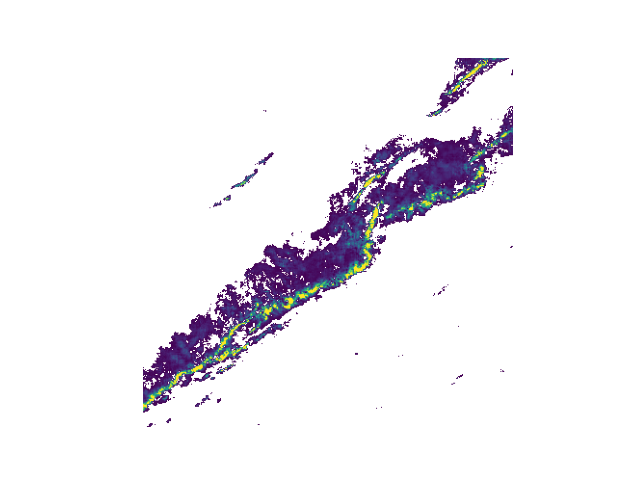

2. 运行定量评估

In [13]:
print("\nRunning quantitative evaluation (from evaluate.py)...")

# 调用 evaluate.py 中封装的评估函数
evaluate(cfg_eval)

print("\nQuantitative evaluation complete. Check the output directory for CSI and PSD plots.")


Running quantitative evaluation (from evaluate.py)...
[2025/06/14 22:29:29] ppsci INFO: Model config: Input=9, Output=20, Total=29
[2025/06/14 22:29:30] ppsci MESSAGE: Finish loading pretrained model from: /mtc/longlingkun/workspace/PaddleScience/examples/nowcastnet/final_model_for_eval/nowcastnet.pdparams
[2025/06/14 22:29:30] ppsci INFO: Using paddlepaddle 3.0.0 on device Place(gpu:0)
[2025/06/14 22:29:30] ppsci MESSAGE: Set to_static=False for computational optimization.
[2025/06/14 22:29:30] ppsci INFO: Start evaluation on 10 samples...
[2025/06/14 22:29:31] ppsci INFO: Case study plot saved to outputs_notebook/normal_eval/case_study_0.png
[2025/06/14 22:29:33] ppsci INFO: Case study plot saved to outputs_notebook/normal_eval/case_study_1.png
[2025/06/14 22:29:35] ppsci INFO: Case study plot saved to outputs_notebook/normal_eval/case_study_2.png
[2025/06/14 22:29:37] ppsci INFO: Case study plot saved to outputs_notebook/normal_eval/case_study_3.png
[2025/06/14 22:29:38] ppsci INFO

可以在对应的输出目录查看到定量分析的结果图

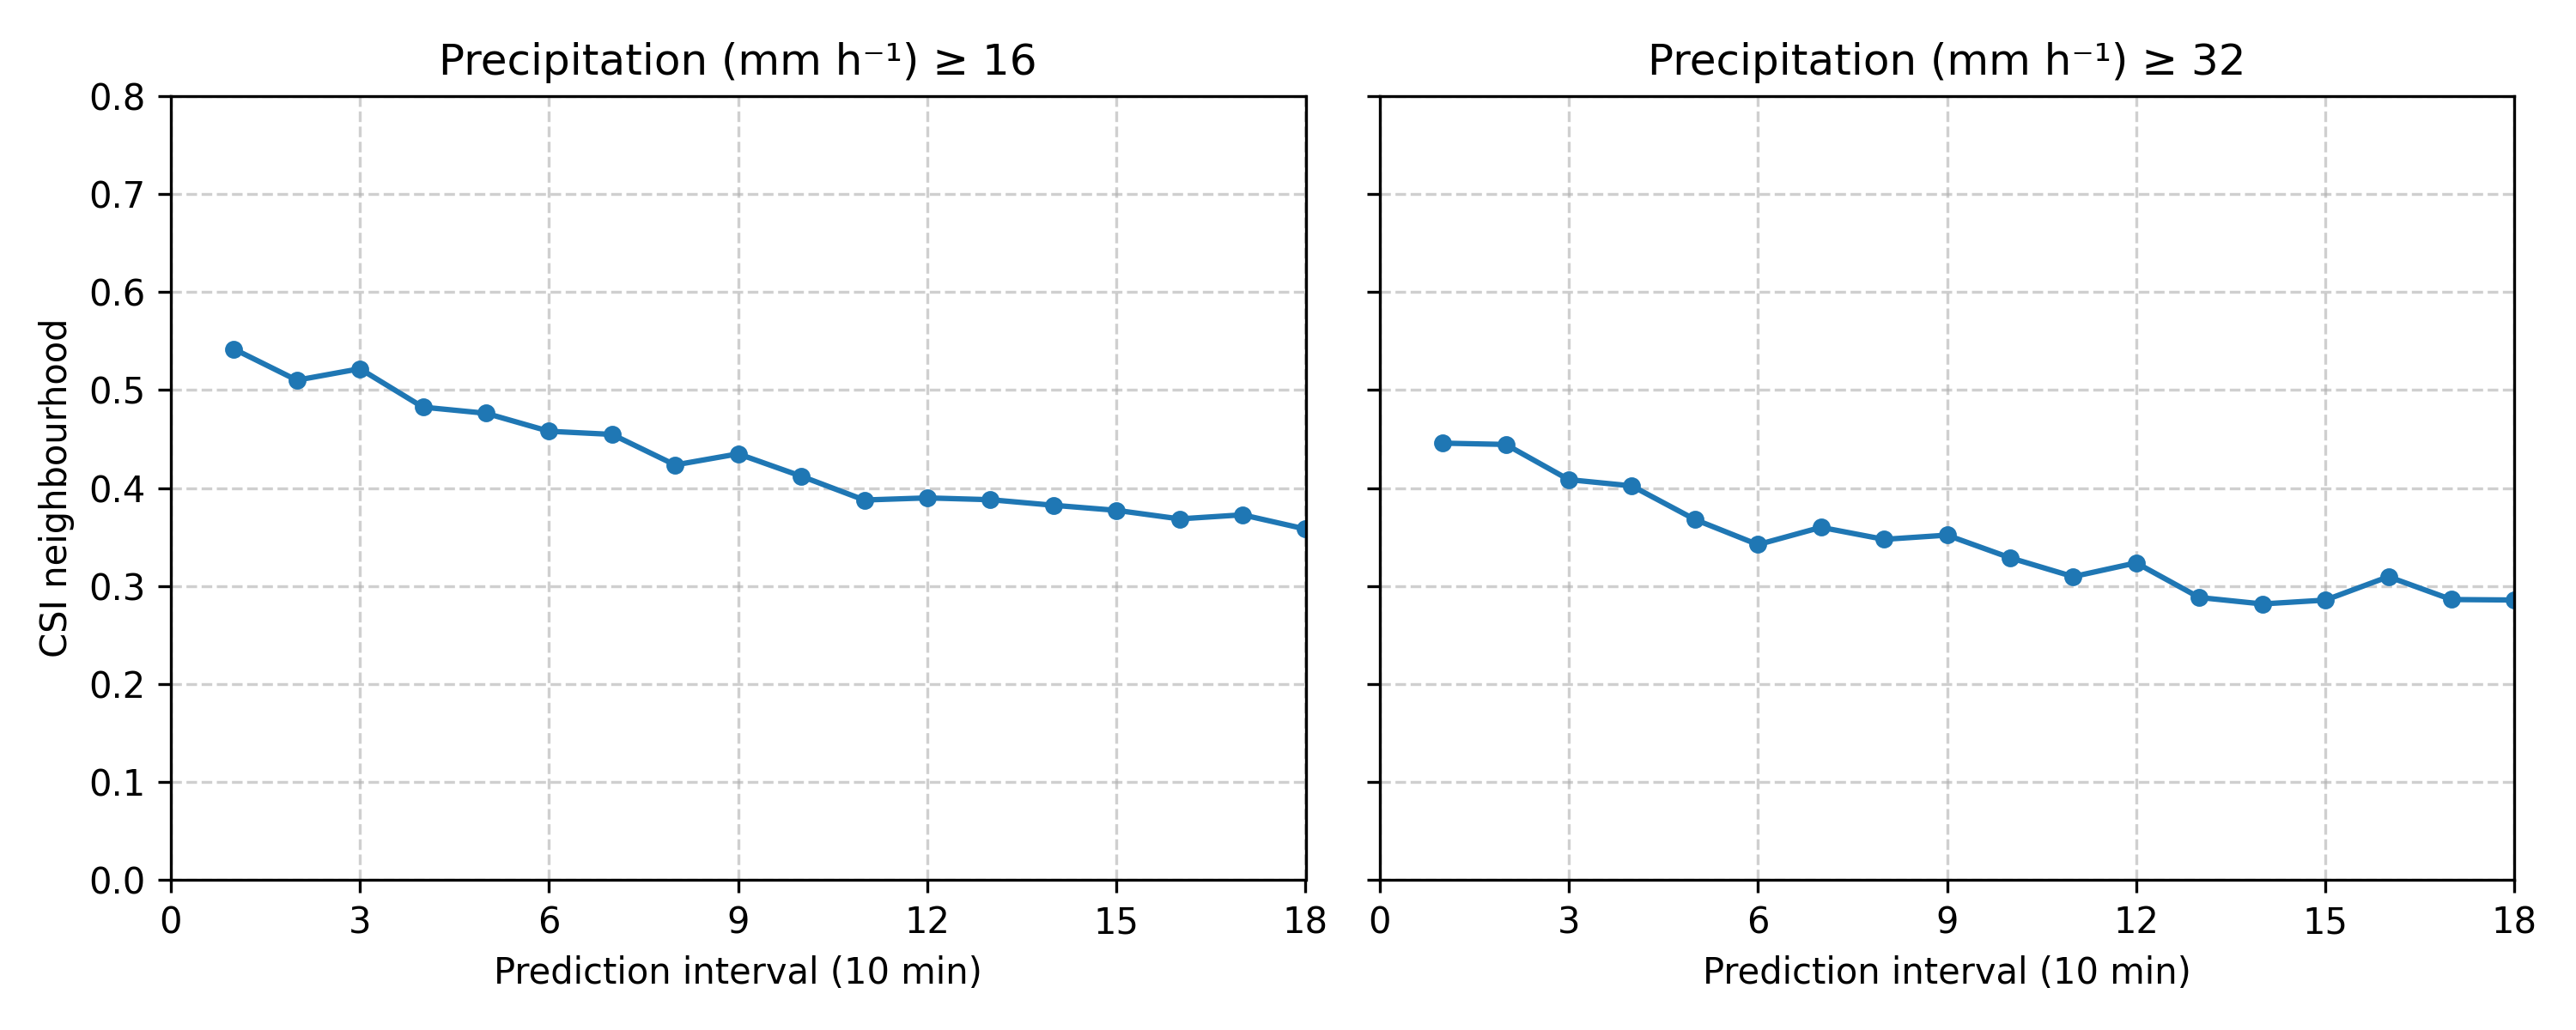
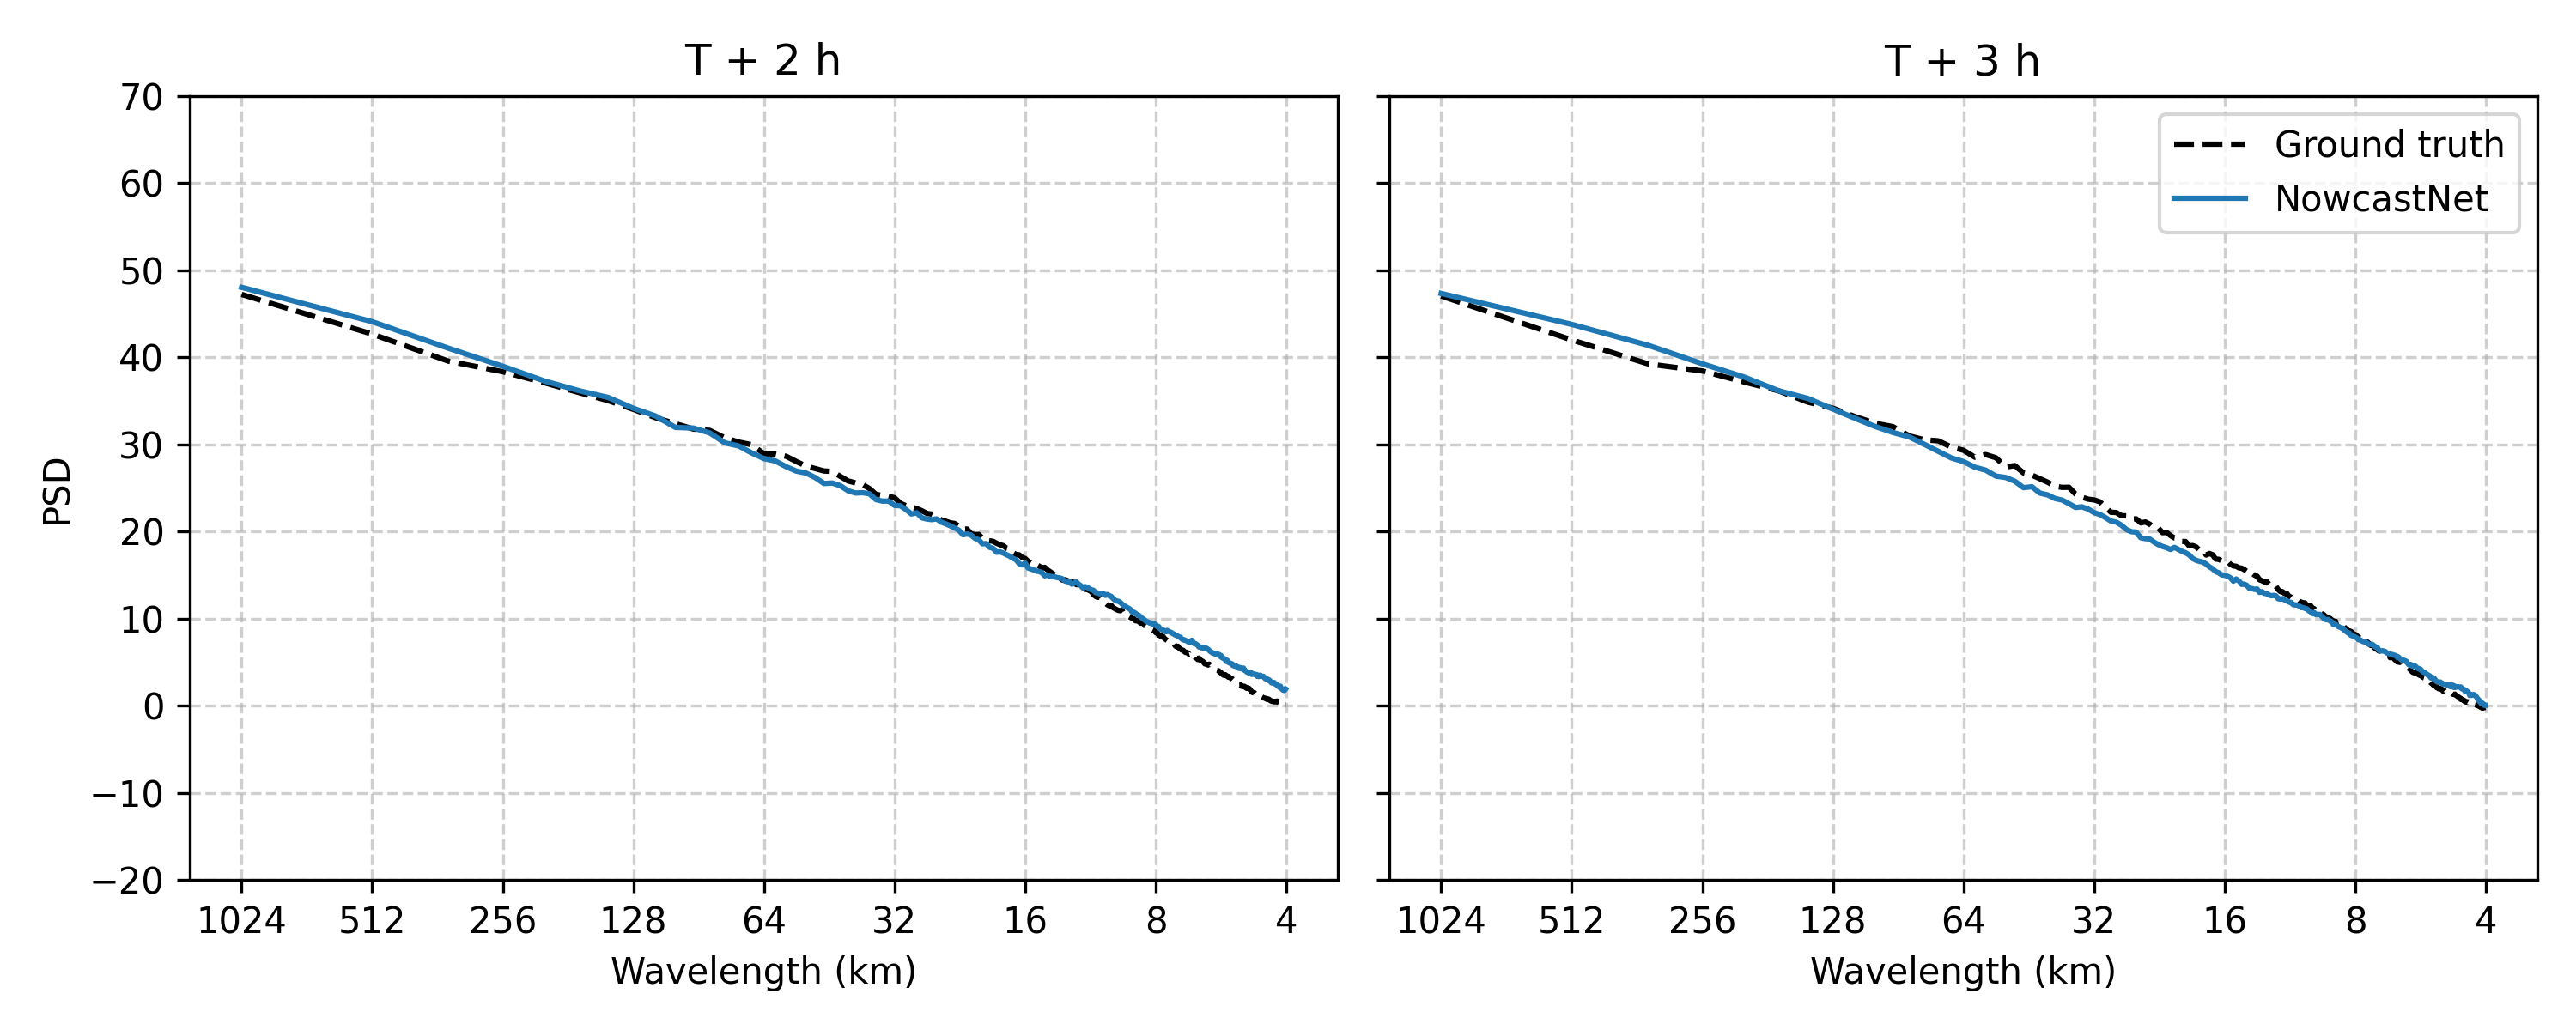